# Penalizing Regressions is Good: Ridge, Lasso, and Elastic Net

<a href="https://www.kaggle.com/code/addarm/penalizing-regressions-is-good" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

![Penalized Regressions](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/penalized_regression_banner.png)

# Introduction

In the [previous article](deep_linear_regression.ipynb), we derived the OLS estimator $\hat{\beta}_{OLS} = (X^TX)^{-1}X^Ty$ and showed that it projects $y$ onto the column space of $X$ through the hat matrix. We also saw that some coefficients had wide confidence intervals, indicating they were poorly determined by the data.

This instability arises from multicollinearity, a setup where the predictors in your design matrix are highly correlated, or worse not independant, and $X^TX$ becomes nearly singular, and its inverse amplifies noise. The resulting coefficient estimates exhibit high variance, making predictions unstable and interpretation unreliable.


## The Bias–Variance Tradeoff

To kick off this article, we need to have a discussion on a well known tradeoff. 

Suppose the true regression coefficients are $\beta$, and our estimator is $\hat{\beta}$. Because our data is random, $\hat{\beta}$ will vary from sample to sample. The natural measure of estimation accuracy is the mean squared error (MSE):

$$
\text{MSE}(\hat{\beta})
=
\mathbb{E}\|\hat{\beta} - \beta\|^2,
$$
$$
\mu = \mathbb{E}[\hat{\beta}].
$$

This represents the expected squared distance between the estimated coefficients and the true coefficients. 

$$
\hat{\beta} - \beta
=
(\mu - \beta) + (\hat{\beta} - \mu)
$$

$$
\mathbb{E}\|\hat{\beta} - \beta\|^2
=
\|\mu - \beta\|^2
+
\mathbb{E}\|\hat{\beta} - \mu\|^2
$$

Using the identity $\|a+b\|^2 = \|a\|^2 + 2a^Tb + \|b\|^2$ same for vector expansion and taking expectations we can remove the cross term:

$$
\|\hat{\beta} - \beta\|^2
=
\|\hat{\beta} - \mu\|^2
+
2(\hat{\beta} - \mu)^T(\mu - \beta)
+
\|\mu - \beta\|^2
$$

$$
\mathbb{E}\|\hat{\beta} - \beta\|^2
=
\mathbb{E}\|\hat{\beta} - \mu\|^2
+
2\,\mathbb{E}\big[(\hat{\beta} - \mu)^T(\mu - \beta)\big]
+
\|\mu - \beta\|^2
$$

The cross-term vanishes because $(\mu - \beta)$ is a fixed, non-random vector (both $\mu = \mathbb{E}[\hat{\beta}]$ and $\beta$ are constants), so it factors out of the expectation, leaving $\mathbb{E}[\hat{\beta} - \mu]^T(\mu - \beta) = \mathbf{0}^T(\mu - \beta) = 0$:

We now have two terms of interest ($\mu$ and $\hat{\beta}$ are the same):
$$
\|\mu-\beta\|^2=\|\mathbb{E}[\hat\beta]-\beta\|^2
$$

$$
\mathbb{E}\|\hat\beta-\mu\|^2
$$

The first measures how far the average estimate is from the truth. This is the squared bias. The second measures how much the estimator fluctuates around its own mean. This is the variance contribution. Because $\hat{\beta}$ is a vector, its variance is a covariance matrix:

$$
\mathrm{Var}(\hat{\beta})
=
\mathbb{E}\big[(\hat{\beta} - \mu)(\hat{\beta} - \mu)^T\big]
$$

$$
\mathbb{E}\|\hat{\beta} - \mu\|^2
=
\mathrm{tr}(\mathrm{Var}(\hat{\beta}))
$$

The total variance entering the MSE is the sum of the individual coefficient variances. That sum is exactly the trace of the covariance matrix ($\mathrm{tr}$). The trace simply means "sum of the diagonal elements", which in this case are the variances of each coefficient. Putting everything together:

$$
\text{MSE}(\hat{\beta})
=
\|\mathbb{E}[\hat{\beta}] - \beta\|^2
+
\mathrm{tr}(\mathrm{Var}(\hat{\beta}))
$$

So total estimation error consists of:

- Error due to being systematically wrong (bias),
- Error due to instability across samples (variance).

But from the previous article, we learned that OLS is unbiased:

$$
\mathbb{E}[\hat{\beta}_{OLS}] = \beta
$$

So if its bias term is zero, what's happenig here? When predictors are highly correlated (multicollinearity), the matrix $X^TX$ becomes ill-conditioned. Small perturbations in the data can then produce large swings in $\hat{\beta}_{OLS}$, meaning Variance becomes large causing coefficient estimates become unstable, making our model sensitive to noise. So here we are hinting that, a slightly biased estimator can outperform an unbiased one if it is much more stable!

This is the central idea behind ridge regression, lasso, and elastic net, the algorithms we briefly mentioned in the last article and will discuss in this. In [Part IV](#part-iv-the-biasvvariance-tradeoff) we will see this tradeoff empirically: the classic Bias² + Variance = MSE curve, showing how total prediction error first decreases then rises as the regularization strength grows.

This article develops three regularization strategies:
1. **Ridge Regression** ($L_2$ penalty): shrinks coefficients toward zero smoothly
2. **Lasso Regression** ($L_1$ penalty): produces sparse solutions by driving some coefficients exactly to zero, similar to feature selection
3. **Elastic Net** (combined $L_1$ + $L_2$): balances the strengths of both approaches

We derive each method, visualize their geometric interpretations, and compare them empirically on the same diabetes dataset used in the previous article.

# Notebook Setup

We import standard numerical and visualization libraries. A fixed random seed ensures reproducibility across all experiments.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
from sklearn.datasets import load_diabetes
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV
from sklearn.model_selection import cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from numpy.linalg import inv, eigvalsh, cond
import warnings

warnings.filterwarnings("ignore")

# Reproducibility
np.random.seed(42)

print("Python:", sys.version.split()[0])
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)
print("Scikit-learn:", sklearn.__version__)

Python: 3.11.14
NumPy: 2.1.3
Pandas: 3.0.0
Scikit-learn: 1.8.0


# The Dataset

We use the same diabetes dataset from the previous article.

In [2]:
# Load the diabetes dataset
diabetes = load_diabetes()
X = diabetes.data
y = diabetes.target
feature_names = diabetes.feature_names

print(f"Design matrix shape: {X.shape}")
print(f"Response vector shape: {y.shape}")
print(f"Features: {feature_names}")
print(f"\nFeature statistics (should be standardized):")
print(f"  Mean: {X.mean(axis=0).round(4)}")
print(f"  Std:  {X.std(axis=0).round(4)}")

Design matrix shape: (442, 10)
Response vector shape: (442,)
Features: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']

Feature statistics (should be standardized):
  Mean: [-0.  0. -0. -0. -0.  0. -0. -0.  0.  0.]
  Std:  [0.0476 0.0476 0.0476 0.0476 0.0476 0.0476 0.0476 0.0476 0.0476 0.0476]


# That Devil Multicollinearity

When we fit OLS, we solve a linear system involving the Gram matrix (design, response, hat, leverage matrix - a lot of names to take in):

$$
X^\top X
$$

If $X^\top X$ is close to singular (almost not invertible, $\det(A) ~ 0$), then the inverse $(X^\top X)^{-1}$ becomes numerically unstable, and the OLS coefficients can swing wildly with tiny changes in the data. For an invertible matrix $A$, the condition number (in the 2-norm) is

$$
\kappa_2(A) = \|A\|_2\,\|A^{-1}\|_2
= \frac{\sigma_{\max}(A)}{\sigma_{\min}(A)}.
$$

- $\sigma_{\max}(A)$ = largest singular value  
- $\sigma_{\min}(A)$ = smallest singular value  

If $\sigma_{\min}(A)$ is very small, then $\kappa_2(A)$ is very large, meaning $A$ is ill-conditioned (near-singular).


For the Gram matrix:

$$
\kappa_2(X^\top X)
=
\frac{\lambda_{\max}(X^\top X)}{\lambda_{\min}(X^\top X)}
=
\left(\frac{\sigma_{\max}(X)}{\sigma_{\min}(X)}\right)^2
=
\kappa_2(X)^2.
$$

So if the columns of $X$ are nearly linearly dependent (multicollinearity), then $\sigma_{\min}(X)\approx 0$, which makes:

- $\kappa_2(X)$ large
- $\kappa_2(X^\top X)$ even larger (squared)

A high condition number indicates near-singularity and potential instability in OLS estimates!

Eigenvalues of X^T X: [0.01 0.08 0.43 0.54 0.6  0.66 0.96 1.21 1.49 4.02]
Condition number: 470.08
Ratio of largest to smallest eigenvalue: 470.08


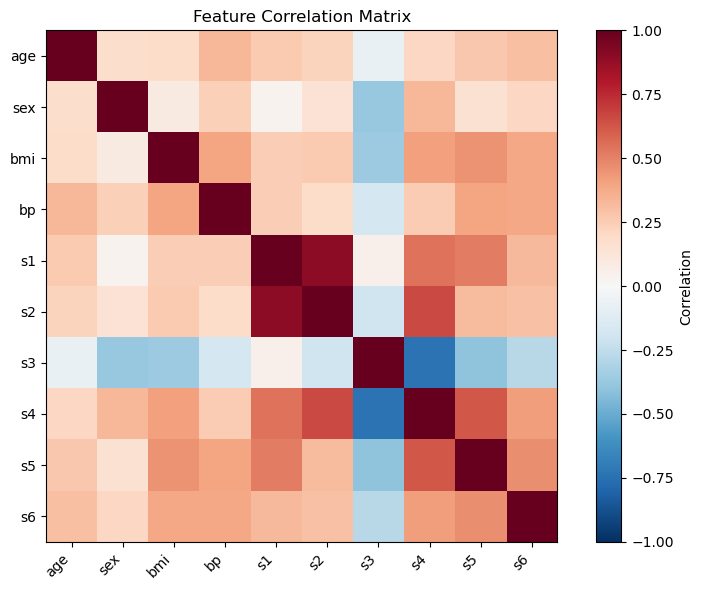

In [3]:
# Compute X^T X and its condition number
XtX = X.T @ X
eigenvalues = eigvalsh(XtX)
condition_number = cond(XtX)

print(f"Eigenvalues of X^T X: {eigenvalues.round(2)}")
print(f"Condition number: {condition_number:.2f}")
print(f"Ratio of largest to smallest eigenvalue: {eigenvalues.max() / eigenvalues.min():.2f}")

# Correlation matrix
corr_matrix = np.corrcoef(X.T)
plt.figure(figsize=(8, 6))
im = plt.imshow(corr_matrix, cmap="RdBu_r", vmin=-1, vmax=1)
plt.colorbar(im, label="Correlation")
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha="right")
plt.yticks(range(len(feature_names)), feature_names)
plt.title("Feature Correlation Matrix")
plt.tight_layout()
plt.show()

# Ridge Regression ($L_2$ Regularization)

Ridge regression modifies OLS by adding an $L_2$ penalty on the coefficient vector. The penalty shrinks coefficients toward zero, which reduces variance when predictors are highly correlated.

The Ridge objective and solution:

$$
\begin{aligned}
\textbf{Objective:} \quad
& \hat{\beta}_{\text{ridge}}
= \arg\min_{\beta}
\left\{
\|y - X\beta\|_2^2 + \lambda \|\beta\|_2^2
\right\}
\\[8pt]
\textbf{Expanded loss:} \quad
& \mathcal{L}(\beta)
= (y - X\beta)^T (y - X\beta)
+ \lambda \beta^T \beta
\\[8pt]
\textbf{Gradient:} \quad
& \nabla_\beta \mathcal{L}
= -2X^T(y - X\beta) + 2\lambda\beta
\\[8pt]
\textbf{Set to zero:} \quad
& -2X^T(y - X\beta) + 2\lambda\beta
= 0
\\[8pt]
\textbf{Rearrange:} \quad
& X^T X \beta + \lambda \beta
= X^T y
\\[8pt]
\textbf{Factor:} \quad
& (X^T X + \lambda I)\beta
= X^T y
\\[8pt]
\textbf{Closed-form solution:} \quad
& \hat{\beta}_{\text{ridge}}
= (X^T X + \lambda I)^{-1} X^T y
\end{aligned}
$$

Here $\lambda \ge 0$ controls the strength of regularization:
- $\lambda = 0$ recovers OLS,
- larger $\lambda$ increases shrinkage.

As we said previously, when predictors are highly correlated, $X^T X$ can be ill-conditioned, therefore its smallest eigenvalue can be close to zero, making $(X^T X)^{-1}$ unstable.

Let the singular values of $X$ be $\sigma_1 \ge \cdots \ge \sigma_p \ge 0$.  
Then the eigenvalues of $X^T X$ are $\sigma_i^2$.

Adding $\lambda I$ shifts every eigenvalue upward:

$$
\text{Eigenvalues of }(X^T X + \lambda I)
=
\sigma_i^2 + \lambda.
$$

So even if $\sigma_{\min}^2 \approx 0$, we get $\sigma_{\min}^2 + \lambda > 0$ whenever $\lambda>0$, which guarantees invertibility.

Using the 2-norm condition number,

$$
\kappa_2(X^T X + \lambda I)
=
\frac{\sigma_{\max}^2 + \lambda}{\sigma_{\min}^2 + \lambda}.
$$

As $\lambda$ increases, the denominator increases more (in relative terms) when $\sigma_{\min}^2$ is small, so $\kappa_2$ decreases toward 1. This is the formal sense in which Ridge makes the inverse more stable.

Ridge introduces some bias (coefficients are shrunk), but often reduces variance enough that the overall MSE improves, especially under multicollinearity. The code below helps us understand this:

In [4]:
def ridge_fit(X, y, lam):
    """
    Compute Ridge regression coefficients using the closed-form solution.

    Parameters:
        X: Design matrix (n x p)
        y: Response vector (n,)
        lam: Regularization parameter lambda >= 0

    Returns:
        beta: Coefficient vector (p,)
    """
    n, p = X.shape
    XtX = X.T @ X
    Xty = X.T @ y
    # Add lambda * I to X^T X
    ridge_matrix = XtX + lam * np.eye(p)
    beta = inv(ridge_matrix) @ Xty
    return beta


# Demonstrate Ridge for several lambda values
lambdas = [0, 0.1, 1, 10, 100, 1000]
print("Ridge coefficients for different λ values:\n")
print(f"{'Feature':>6}", end="")
for lam in lambdas:
    print(f"  λ={lam:>5}", end="")
print()
print("-" * 60)

for i, name in enumerate(feature_names):
    print(f"{name:>6}", end="")
    for lam in lambdas:
        beta_ridge = ridge_fit(X, y, lam)
        print(f"  {beta_ridge[i]:>7.1f}", end="")
    print()

Ridge coefficients for different λ values:

Feature  λ=    0  λ=  0.1  λ=    1  λ=   10  λ=  100  λ= 1000
------------------------------------------------------------
   age    -10.0      1.3     29.5     19.8      2.9      0.3
   sex   -239.8   -207.2    -83.2     -0.9      0.6      0.1
   bmi    519.8    489.7    306.4     75.4      9.2      0.9
    bp    324.4    301.8    201.6     55.0      6.9      0.7
    s1   -792.2    -83.5      5.9     19.9      3.2      0.3
    s2    476.7    -70.8    -29.5     13.9      2.6      0.3
    s3    101.0   -188.7   -152.0    -47.6     -6.2     -0.6
    s4    177.1    115.7    117.3     48.3      6.7      0.7
    s5    751.3    443.8    262.9     70.1      8.9      0.9
    s6     67.6     86.7    111.9     44.2      6.0      0.6


The table shows how Ridge regression coefficients evolve as the regularization parameter $\lambda$ increases. Several important patterns appear:

1. When $\lambda = 0$, the solution is exactly the ordinary least squares'.  
   We observe very large coefficients (e.g., `s1 = -792.2`, `s5 = 751.3`), indicating instability due to multicollinearity.

2. Even at $\lambda = 0.1$, coefficients shrink substantially.  
   The extreme magnitudes collapse quickly, with lambdas conditioning.

3. For $\lambda = 1000$, nearly all coefficients are close to zero - but not zero, that's for the next algo  
   This is the shrinkage effect of the $L_2$ penalty

The dramatic change between $\lambda = 0$ and $\lambda = 0.1$ shows how sensitive OLS is to small perturbations when predictors are correlated. Ridge shrinks all coefficients toward zero, but never exactly to zero. The coefficient paths show smooth, continuous shrinkage as the plot below:

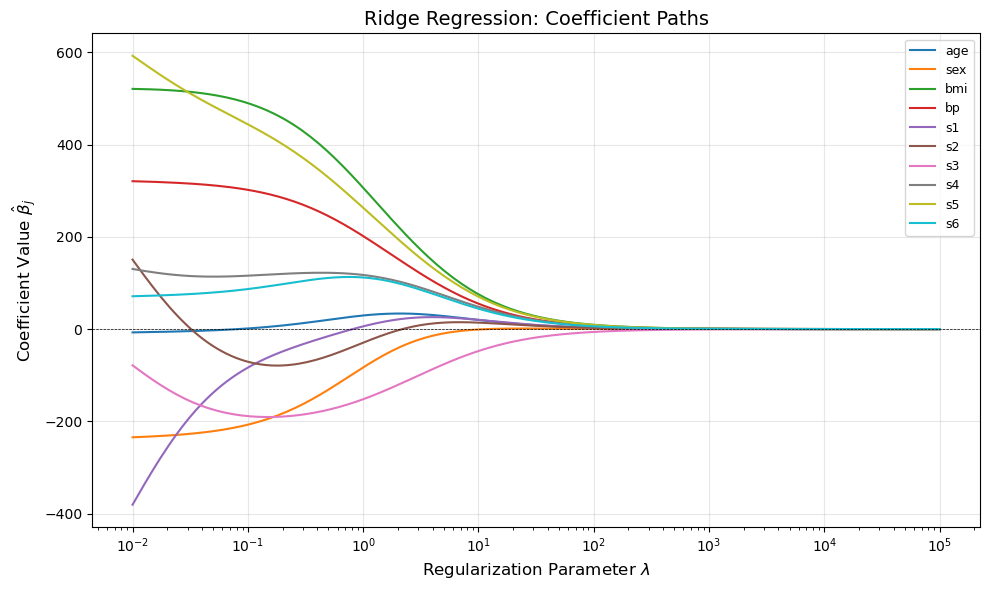

In [5]:
# Compute coefficient paths for Ridge
lambda_range = np.logspace(-2, 5, 200)
ridge_coefs = np.zeros((len(lambda_range), X.shape[1]))

for i, lam in enumerate(lambda_range):
    ridge_coefs[i, :] = ridge_fit(X, y, lam)

# Plot coefficient paths
plt.figure(figsize=(10, 6))
for j, name in enumerate(feature_names):
    plt.plot(lambda_range, ridge_coefs[:, j], label=name, linewidth=1.5)

plt.xscale("log")
plt.xlabel(r"Regularization Parameter $\lambda$", fontsize=12)
plt.ylabel(r"Coefficient Value $\hat{\beta}_j$", fontsize=12)
plt.title("Ridge Regression: Coefficient Paths", fontsize=14)
plt.legend(loc="upper right", fontsize=9)
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

So far, we argued analytically that Ridge shifts eigenvalues and reduces the condition number.  
Now we verify this numerically with code that get the Gram matrix, extracts the eigenvales, computes the condition and plots it for us:

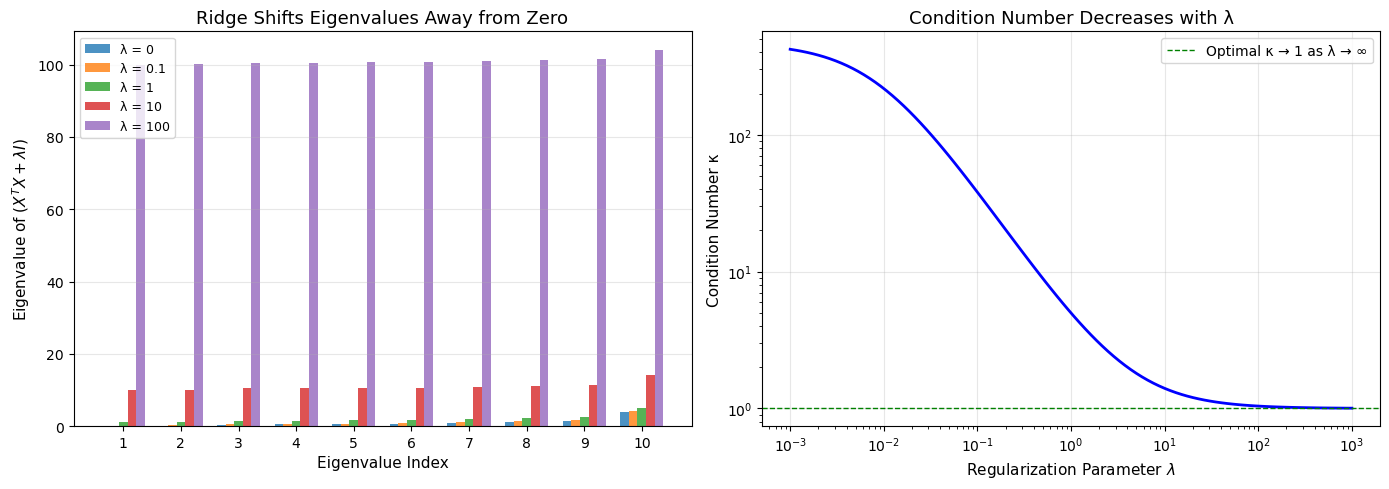

Original condition number (λ=0): 470.08
Condition number at λ=10: 1.40
Condition number at λ=100: 1.04


In [6]:
# Visualize eigenvalue stabilization
XtX = X.T @ X
eigenvalues_raw = eigvalsh(XtX)

lambda_values = [0, 0.1, 1, 10, 100]
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left panel: effect on eigenvalues of (X^T X + lambda I)
ax = axes[0]
x_positions = np.arange(len(eigenvalues_raw))
width = 0.15

for i, lam in enumerate(lambda_values):
    shifted_eigs = eigenvalues_raw + lam
    ax.bar(x_positions + i * width, shifted_eigs, width, label=f"λ = {lam}", alpha=0.8)

ax.set_xlabel("Eigenvalue Index", fontsize=11)
ax.set_ylabel("Eigenvalue of $(X^TX + \\lambda I)$", fontsize=11)
ax.set_title("Ridge Shifts Eigenvalues Away from Zero", fontsize=13)
ax.legend(fontsize=9)
ax.set_xticks(x_positions + 2 * width)
ax.set_xticklabels([f"{i + 1}" for i in x_positions])
ax.grid(True, alpha=0.3, axis="y")

# Right panel: condition number as lambda increases
ax = axes[1]
lambda_range_cond = np.logspace(-3, 3, 100)
condition_numbers = np.zeros(len(lambda_range_cond))

for i, lam in enumerate(lambda_range_cond):
    shifted_eigs = eigenvalues_raw + lam
    condition_numbers[i] = shifted_eigs.max() / shifted_eigs.min()

ax.plot(lambda_range_cond, condition_numbers, "b-", linewidth=2)
ax.axhline(y=condition_numbers[-1], color="green", linestyle="--", linewidth=1, label=f"Optimal κ → 1 as λ → ∞")
ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlabel(r"Regularization Parameter $\lambda$", fontsize=11)
ax.set_ylabel("Condition Number κ", fontsize=11)
ax.set_title("Condition Number Decreases with λ", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Original condition number (λ=0): {cond(XtX):.2f}")
print(f"Condition number at λ=10: {(eigenvalues_raw.max() + 10) / (eigenvalues_raw.min() + 10):.2f}")
print(f"Condition number at λ=100: {(eigenvalues_raw.max() + 100) / (eigenvalues_raw.min() + 100):.2f}")

The left plot shows that as we increase $\lambda$, every eigenvalue simply shifts upward.  
The smallest ones, i.e. the dangerous ones, move away from zero.

The right plot shows the consequence: the condition number drops quickly as $\lambda$ increases. When $\lambda = 0$, the matrix is poorly conditioned. As $\lambda$ grows, the matrix becomes more stable.

That is the entire stabilization mechanism behind Ridge!

### Ridge Hat Matrix and Effective Degrees of Freedom

$$
\begin{aligned}
\textbf{OLS hat matrix:} \quad
H
&= X (X^T X)^{-1} X^T
\\[6pt]
\textbf{Ridge hat matrix:} \quad
H_\lambda
&= X (X^T X + \lambda I)^{-1} X^T
\\[10pt]
\textbf{Effective degrees of freedom:} \quad
\text{df}(\lambda)
&= \mathrm{tr}(H_\lambda)
= \sum_{j=1}^{p}
\frac{\sigma_j^2}{\sigma_j^2 + \lambda}
\end{aligned}
$$

As $\lambda \to 0$, we recover OLS and:
$$
\text{df}(\lambda) \to p.
$$

As $\lambda \to \infty$:
$$
\text{df}(\lambda) \to 0.
$$

In OLS, the hat matrix projects the response vector $y$ exactly onto the column space of $X$. Its trace equals $p$, the number of parameters, meaning OLS fully uses all $p$ degrees of freedom (refer to the previous article). Ridge modifies that projection.

Because of the regularization term $\lambda$, the model behaves as if it uses fewer effective parameters. The quantity:

$$
\text{df}(\lambda) = \mathrm{tr}(H_\lambda)
$$

measures this continuous reduction in model complexity.

- Small $\lambda$ -> $\text{df}$ close to $p$ → little shrinkage  
- Large $\lambda$ -> $\text{df}$ small → strong shrinkage  

This provides a clean mathematical link to the bias–variance tradeoff:

- Lower degrees of freedom → higher bias, lower variance  
- Higher degrees of freedom → lower bias, higher variance  


The diagonal elements of $H_\lambda$ (the leverage values) are smaller than in OLS. This means each observation has less influence on its own fitted value. Let's observe this with code:

Effective Degrees of Freedom (out of p predictors):
--------------------------------------------------
  λ =      0: df = 10.00
  λ =    0.1: df = 7.64
  λ =      1: df = 3.94
  λ =     10: df = 0.83
  λ =    100: df = 0.10
  λ =   1000: df = 0.01


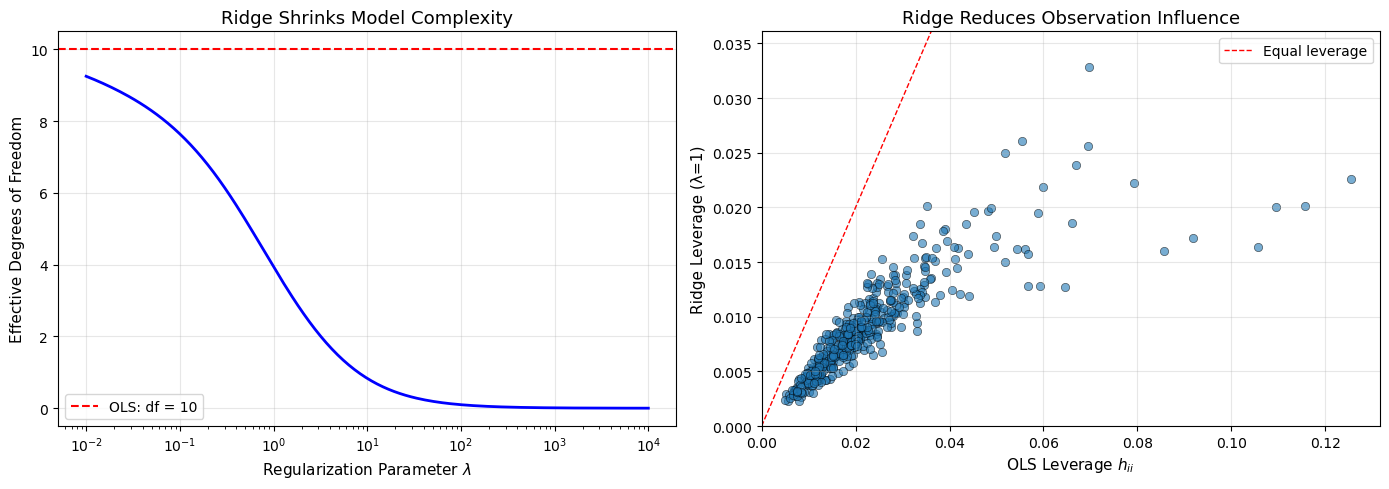


OLS: sum of leverages = 10.00 (= p = 10)
Ridge (λ=1): sum of leverages = 3.94


In [7]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import inv, eigvalsh


def effective_df(X, lam):
    XtX = X.T @ X
    eigenvalues = eigvalsh(XtX)
    return np.sum(eigenvalues / (eigenvalues + lam))


def ridge_hat_matrix(X, lam):
    n, p = X.shape
    XtX = X.T @ X
    return X @ inv(XtX + lam * np.eye(p)) @ X.T


lambda_vals_df = [0, 0.1, 1, 10, 100, 1000]

print("Effective Degrees of Freedom (out of p predictors):")
print("-" * 50)
for lam in lambda_vals_df:
    df = effective_df(X, lam)
    print(f"  λ = {lam:>6}: df = {df:.2f}")


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Effective df vs lambda
lambda_range_df = np.logspace(-2, 4, 200)
df_values = [effective_df(X, lam) for lam in lambda_range_df]

ax = axes[0]
ax.plot(lambda_range_df, df_values, "b-", linewidth=2)
ax.axhline(y=X.shape[1], color="red", linestyle="--", label=f"OLS: df = {X.shape[1]}")

ax.set_xscale("log")
ax.set_xlabel(r"Regularization Parameter $\lambda$", fontsize=11)
ax.set_ylabel("Effective Degrees of Freedom", fontsize=11)
ax.set_title("Ridge Shrinks Model Complexity", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)


# Right: Leverage comparison
ridge_lambda = 1  # moderate shrinkage for visualization

H_ols = ridge_hat_matrix(X, lam=0)
H_ridge = ridge_hat_matrix(X, lam=ridge_lambda)

leverage_ols = np.diag(H_ols)
leverage_ridge = np.diag(H_ridge)

ax = axes[1]
ax.scatter(leverage_ols, leverage_ridge, alpha=0.6, edgecolors="k", linewidth=0.5)

max_val = max(leverage_ols.max(), leverage_ridge.max())
ax.plot([0, max_val], [0, max_val], "r--", linewidth=1, label="Equal leverage")

ax.set_xlim(0, leverage_ols.max() * 1.05)
ax.set_ylim(0, leverage_ridge.max() * 1.10)

ax.set_xlabel("OLS Leverage $h_{ii}$", fontsize=11)
ax.set_ylabel(f"Ridge Leverage (λ={ridge_lambda})", fontsize=11)
ax.set_title("Ridge Reduces Observation Influence", fontsize=13)
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


print(f"\nOLS: sum of leverages = {leverage_ols.sum():.2f} (= p = {X.shape[1]})")
print(f"Ridge (λ={ridge_lambda}): sum of leverages = {leverage_ridge.sum():.2f}")


The Left plot shows Model complexity shrinkage, as ridge gives us a smooth way to control model complexity.

While the right shows how teh influence is reduced, as all points lie below the red OLS leverage line.

## Lasso Regression ($L_1$ Regularization)


Lasso is similar to Ridge, but instead of squaring the coefficients, it penalizes their absolute values. The Lasso Objective and solution:

$$
\hat{\beta}_{lasso}
=
\arg\min_{\beta}
\left\{
\|y - X\beta\|_2^2
+
\lambda \|\beta\|_1
\right\}
$$

where

$$
\|\beta\|_1 = \sum_{j=1}^{p} |\beta_j|.
$$

The key difference from Ridge is the absolute value penalty. Also unlike Ridge, Lasso does not have a simple cllosed form formula like:

$$
(X^T X + \lambda I)^{-1} X^T y.
$$


The absolute value function is not smooth at zero. We cannot just take derivatives and solve directly. Instead, Lasso is solved using iterative methods (we'll use coordinate descent later), so

- Ridge **shrinks** coefficients. Its shape is a smooth ball
- Lasso can **shrink them exactly to zero**. Its a diamond with sharp corners, bad for differentiating.

When we minimize the error under this diamond constraint, the solution often hits a corner. Corners lie on the axes. Points on the axes mean:

$$
\beta_j = 0
$$

So Lasso performs automatic feature selection.

The basic update rule in Lasso uses:

$$
S_\lambda(z)
=
\text{sign}(z)\,\max(|z| - \lambda, 0).
$$

This rule:

- Shrinks large values slightly,
- Pushes small values exactly to zero.

That is the mathematical reason Lasso creates "sparse models". The figure below demostrates this geometry:

![Penalized Regressions Example](https://raw.githubusercontent.com/adamd1985/quant_research/refs/heads/main/images/penalized_regression_example.png)

The Left Panel is the Ridge ($L_2$).

The blue circle represents the $L_2$ constraint. The red ellipses are contours of the error (RSS). The solution occurs where the ellipse first touches the circle.

Because the circle is smooth everywhere, the contact point usually has:

- Both $\beta_1 \neq 0$
- $\beta_2 \neq 0$

So Ridge shrinks coefficients, but rarely sets them exactly to zero.

While the right Panel is Lasso ($L_1$).

The green diamond represents the $L_1$ constraint. Notice it has sharp corners on the axes. When the error contours expand outward, they often touch the diamond at a corner. Corners lie on the axes, that means:

$$
\beta_1 = 0
\quad \text{or} \quad
\beta_2 = 0.
$$

This is exactly what we saw earlier, Lasso can produce sparse solutions. Same as the Ridge plot, the code below plots the coefficient paths:

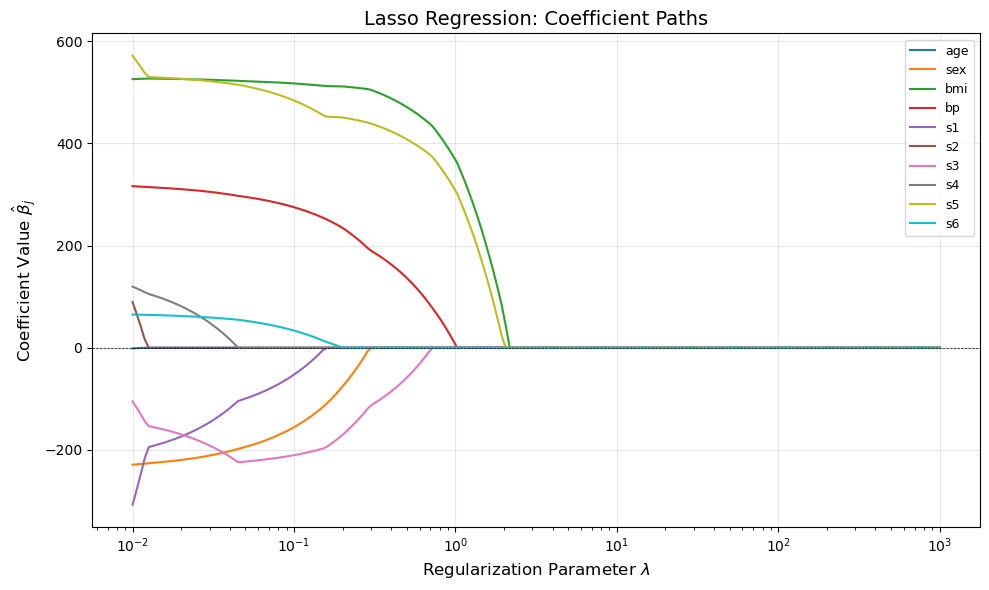

In [8]:
# Lasso coefficient paths
lambda_range_lasso = np.logspace(-2, 3, 200)
lasso_coefs = np.zeros((len(lambda_range_lasso), X.shape[1]))

for i, lam in enumerate(lambda_range_lasso):
    # sklearn Lasso uses alpha = lambda / (2*n) scaling
    # We use alpha directly as the penalty parameter
    lasso = Lasso(alpha=lam, fit_intercept=False, max_iter=10000)
    lasso.fit(X, y)
    lasso_coefs[i, :] = lasso.coef_

# Plot coefficient paths
plt.figure(figsize=(10, 6))
for j, name in enumerate(feature_names):
    plt.plot(lambda_range_lasso, lasso_coefs[:, j], label=name, linewidth=1.5)

plt.xscale("log")
plt.xlabel(r"Regularization Parameter $\lambda$", fontsize=12)
plt.ylabel(r"Coefficient Value $\hat{\beta}_j$", fontsize=12)
plt.title("Lasso Regression: Coefficient Paths", fontsize=14)
plt.legend(loc="upper right", fontsize=9)
plt.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Why Lasso Zeroes things - The Soft-Thresholding Operator

Lasso does not have a simple formula in general. But in one special case, when the predictors are orthonormal ($X^T X = I$), the solution becomes very simple and reveals the key solution.

For each coefficient:

$$
\hat{\beta}_j^{lasso}
=
\text{sign}(\hat{\beta}_j^{OLS})
\cdot
\max\big(|\hat{\beta}_j^{OLS}| - \lambda,\, 0\big)
$$

This rule is called soft-thresholding. It takes the OLS coefficient and:

- Shrinks it toward zero by $\lambda$.
- If the coefficient is smaller than $\lambda$ in magnitude, it becomes exactly zero.


In the same orthonormal case, Ridge gives:

$$
\hat{\beta}_j^{ridge}
=
\frac{\hat{\beta}_j^{OLS}}{1 + \lambda}.
$$

Ridge shrinks proportionally. Lasso shrinks by a fixed amount and can set values to zero. The code below helps us understand this:

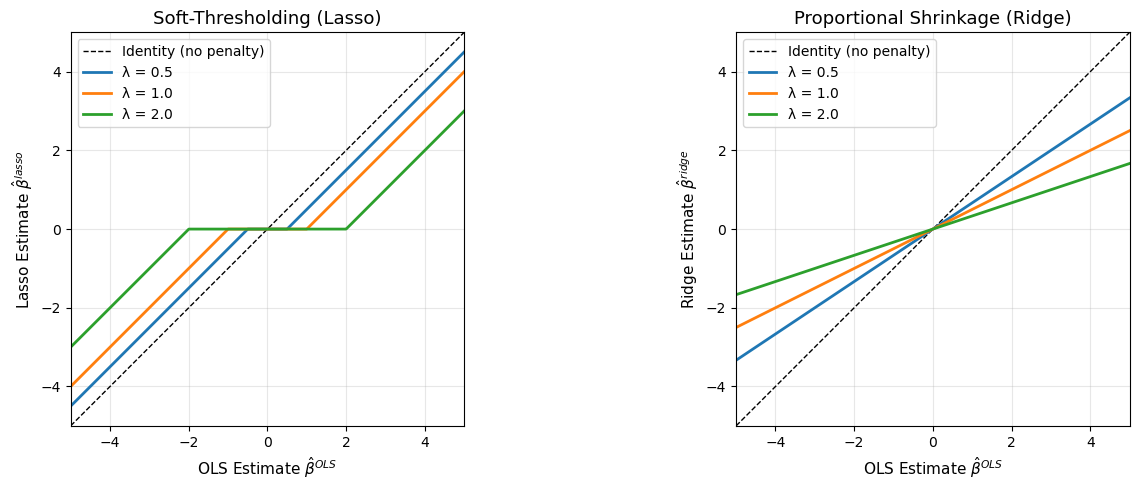

In [9]:
# Visualize soft-thresholding (Lasso) vs proportional shrinkage (Ridge)
def soft_threshold(z, lam):
    """Soft-thresholding operator for Lasso."""
    return np.sign(z) * np.maximum(np.abs(z) - lam, 0)


def ridge_shrinkage(z, lam):
    """Proportional shrinkage for Ridge."""
    return z / (1 + lam)


z_vals = np.linspace(-5, 5, 1000)
lambda_vals = [0.5, 1.0, 2.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Soft-thresholding (Lasso)
ax = axes[0]
ax.plot(z_vals, z_vals, "k--", linewidth=1, label="Identity (no penalty)")
for lam in lambda_vals:
    ax.plot(z_vals, soft_threshold(z_vals, lam), linewidth=2, label=f"λ = {lam}")
ax.set_xlabel(r"OLS Estimate $\hat{\beta}^{OLS}$", fontsize=11)
ax.set_ylabel(r"Lasso Estimate $\hat{\beta}^{lasso}$", fontsize=11)
ax.set_title("Soft-Thresholding (Lasso)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect("equal")

# Right: Proportional shrinkage (Ridge)
ax = axes[1]
ax.plot(z_vals, z_vals, "k--", linewidth=1, label="Identity (no penalty)")
for lam in lambda_vals:
    ax.plot(z_vals, ridge_shrinkage(z_vals, lam), linewidth=2, label=f"λ = {lam}")
ax.set_xlabel(r"OLS Estimate $\hat{\beta}^{OLS}$", fontsize=11)
ax.set_ylabel(r"Ridge Estimate $\hat{\beta}^{ridge}$", fontsize=11)
ax.set_title("Proportional Shrinkage (Ridge)", fontsize=13)
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
ax.set_xlim(-5, 5)
ax.set_ylim(-5, 5)
ax.set_aspect("equal")

plt.tight_layout()
plt.show()

## The Coordinate Descent Algorithm

As we said, Lasso has no simple closed-form formula. Instead, we use coordinate descent, where we update one coefficient at a time, while keeping the others fixed.

This works because when we fix all other coefficients, the problem becomes one-dimensional, and in one dimension, we know the solution: soft-thresholding.

For each feature $j$:

1. Compute the partial residual (the part of $y$ not explained by the other variables):

   $$
   r_j = y - \sum_{k \neq j} X_k \beta_k
   $$

2. Measure how strongly feature $j$ correlates with that residual:

   $$
   \rho_j = X_j^T r_j
   $$

3. Update $\beta_j$ using soft-thresholding:

   $$
   \beta_j
   =
   \frac{\text{sign}(\rho_j)\,\max(|\rho_j| - \lambda, 0)}
   {X_j^T X_j}
   $$

Because Lasso is convex, this process converges to the global minimum. The code below goes through this algo:

In [10]:
def lasso_coordinate_descent(X, y, alpha, max_iter=1000, tol=1e-6):
    """
    Solve Lasso using coordinate descent.

    Minimizes: (1/2n)||y - X*beta||^2 + alpha * ||beta||_1
    (matches sklearn's convention)

    Parameters:
        X: Design matrix (n x p), assumed standardized
        y: Response vector (n,)
        alpha: Regularization parameter (sklearn convention)
        max_iter: Maximum iterations
        tol: Convergence tolerance

    Returns:
        beta: Coefficient vector (p,)
        history: List of objective values
    """
    n, p = X.shape
    beta = np.zeros(p)
    history = []

    # Precompute X_j^T X_j for each feature
    XtX_diag = np.sum(X**2, axis=0)

    # sklearn uses (1/2n)||y - Xb||^2 + alpha||b||_1
    # Soft-thresholding threshold = n * alpha (scaled to match the gradient)
    lam_scaled = n * alpha

    for iteration in range(max_iter):
        beta_old = beta.copy()

        for j in range(p):
            # Partial residual (excluding feature j's contribution)
            r_j = y - X @ beta + X[:, j] * beta[j]

            # Univariate OLS estimate: rho_j = X_j' * r_j
            rho_j = X[:, j].T @ r_j

            # Soft-thresholding update
            if XtX_diag[j] > 0:
                beta[j] = soft_threshold(rho_j, lam_scaled) / XtX_diag[j]
            else:
                beta[j] = 0

        # Compute objective for convergence check (sklearn convention)
        residual = y - X @ beta
        obj = (0.5 / n) * np.sum(residual**2) + alpha * np.sum(np.abs(beta))
        history.append(obj)

        # Check convergence
        if np.max(np.abs(beta - beta_old)) < tol:
            break

    return beta, history

Watch how the objective function decreases and coefficients evolve during coordinate descent:

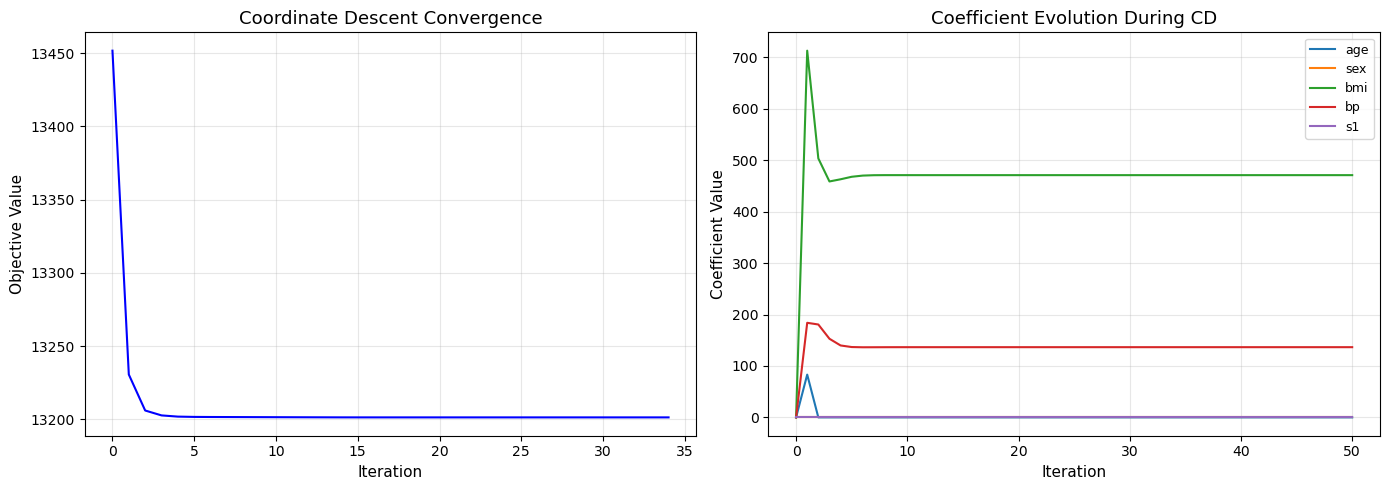

In [11]:
# Run coordinate descent to get convergence history
beta_cd, history = lasso_coordinate_descent(X, y, alpha=0.1)

# Visualize convergence
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Objective function convergence
ax = axes[0]
ax.plot(history, "b-", linewidth=1.5)
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("Objective Value", fontsize=11)
ax.set_title("Coordinate Descent Convergence", fontsize=13)
ax.grid(True, alpha=0.3)

# Right: Coefficient evolution during CD
alpha_vis = 0.5
n_obs = X.shape[0]
beta_vis = np.zeros(X.shape[1])
coef_history = [beta_vis.copy()]
XtX_diag = np.sum(X**2, axis=0)
lam_vis_scaled = n_obs * alpha_vis

for _ in range(50):
    for j in range(X.shape[1]):
        r_j = y - X @ beta_vis + X[:, j] * beta_vis[j]
        rho_j = X[:, j].T @ r_j
        beta_vis[j] = soft_threshold(rho_j, lam_vis_scaled) / XtX_diag[j] if XtX_diag[j] > 0 else 0
    coef_history.append(beta_vis.copy())

coef_history = np.array(coef_history)

ax = axes[1]
for j in range(min(5, X.shape[1])):  # Plot first 5 features
    ax.plot(coef_history[:, j], label=feature_names[j], linewidth=1.5)
ax.set_xlabel("Iteration", fontsize=11)
ax.set_ylabel("Coefficient Value", fontsize=11)
ax.set_title("Coefficient Evolution During CD", fontsize=13)
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Elastic Net: Combining Shrinkage and Selection

If Ridge shrinks coefficients, and Lasso shrinks and can set some to zero, then Elastic Net combines both ideas. Elastic Net minimizes squared error while applying both penalties:

$$
\hat{\beta}_{enet}
=
\arg\min_{\beta}
\left\{
\|y - X\beta\|_2^2
+
\lambda_1 \|\beta\|_1
+
\lambda_2 \|\beta\|_2^2
\right\}.
$$

The $L_1$ term encourages sparsity. The $L_2$ term stabilizes the solution.

Lasso works well for selecting variables, but it has a weakness: When predictors are highly correlated, Lasso often selects one and discards the others. The choice can be somewhat arbitrary.

Ridge behaves differently. It tends to keep correlated predictors together by shrinking them toward similar values.

Elastic Net blends these behaviors:

- It can remove unimportant variables (like Lasso).
- It keeps correlated predictors more stable (like Ridge).


In practice, we usually control Elastic Net with $\alpha$ for strenght, and $\rho$ as the ratio between L1 and L2.

$$
\|y - X\beta\|_2^2
+
\alpha \rho \|\beta\|_1
+
\frac{\alpha(1-\rho)}{2} \|\beta\|_2^2.
$$

So:

- $\rho = 1$ is Lasso  
- $\rho = 0$ is Ridge  
- $0 < \rho < 1$ is the Elastic Net  

Elastic Net gives you a continuous spectrum between the two extremes, as we can see in the code and plot below:

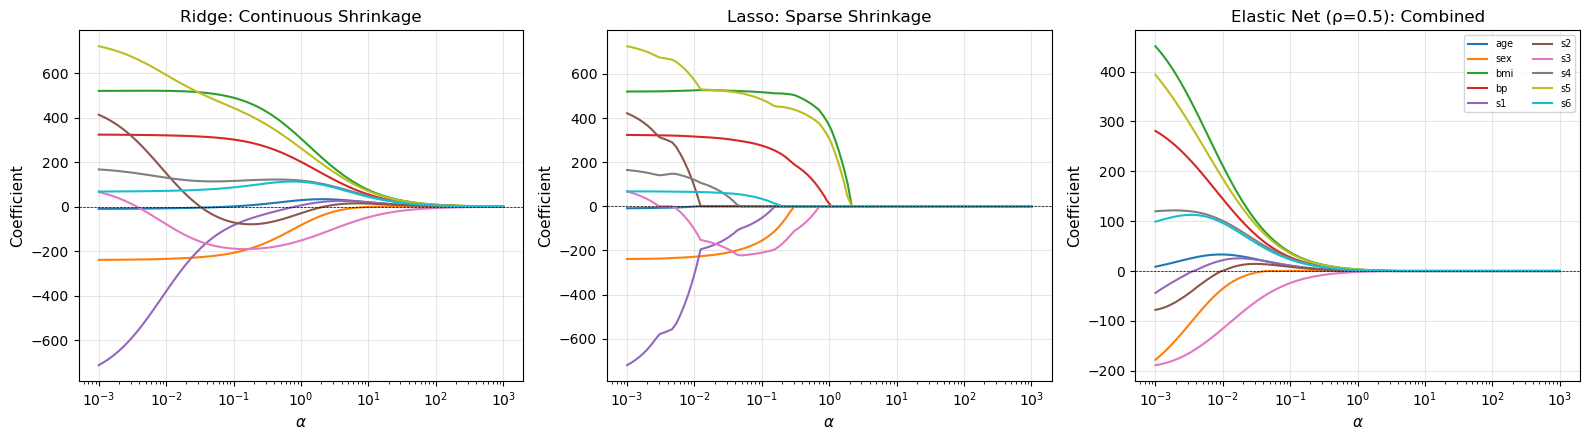

In [12]:
# Combined coefficient path comparison
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))

# Common alpha range
alpha_range = np.logspace(-3, 3, 100)

# Ridge paths
ridge_paths = np.zeros((len(alpha_range), X.shape[1]))
for i, alpha in enumerate(alpha_range):
    ridge_paths[i, :] = ridge_fit(X, y, alpha)

ax = axes[0]
for j, name in enumerate(feature_names):
    ax.plot(alpha_range, ridge_paths[:, j], linewidth=1.5)
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha$", fontsize=11)
ax.set_ylabel("Coefficient", fontsize=11)
ax.set_title("Ridge: Continuous Shrinkage", fontsize=12)
ax.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
ax.grid(True, alpha=0.3)

# Lasso paths
lasso_paths = np.zeros((len(alpha_range), X.shape[1]))
for i, alpha in enumerate(alpha_range):
    lasso = Lasso(alpha=alpha, fit_intercept=False, max_iter=10000)
    lasso.fit(X, y)
    lasso_paths[i, :] = lasso.coef_

ax = axes[1]
for j, name in enumerate(feature_names):
    ax.plot(alpha_range, lasso_paths[:, j], linewidth=1.5)
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha$", fontsize=11)
ax.set_ylabel("Coefficient", fontsize=11)
ax.set_title("Lasso: Sparse Shrinkage", fontsize=12)
ax.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
ax.grid(True, alpha=0.3)

# Elastic Net paths (l1_ratio = 0.5)
enet_paths = np.zeros((len(alpha_range), X.shape[1]))
for i, alpha in enumerate(alpha_range):
    enet = ElasticNet(alpha=alpha, l1_ratio=0.5, fit_intercept=False, max_iter=10000)
    enet.fit(X, y)
    enet_paths[i, :] = enet.coef_

ax = axes[2]
for j, name in enumerate(feature_names):
    ax.plot(alpha_range, enet_paths[:, j], linewidth=1.5, label=name)
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha$", fontsize=11)
ax.set_ylabel("Coefficient", fontsize=11)
ax.set_title("Elastic Net (ρ=0.5): Combined", fontsize=12)
ax.axhline(y=0, color="black", linestyle="--", linewidth=0.5)
ax.legend(loc="upper right", fontsize=7, ncol=2)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Count zeros at a moderate alpha
alpha_test = 1.0
lasso_test = Lasso(alpha=alpha_test, fit_intercept=False, max_iter=10000).fit(X, y)
enet_test = ElasticNet(alpha=alpha_test, l1_ratio=0.5, fit_intercept=False, max_iter=10000).fit(X, y)
ridge_test = ridge_fit(X, y, alpha_test)

# The Bias–Variance Tradeoff in Practice

In the coefficient-path plots above we saw what Ridge, Lasso, and Elastic Net *do* mechanically: as the penalty strength $\lambda$ grows, coefficients shrink (Ridge) or are driven to zero (Lasso/Elastic Net). But that raises the obvious question, how much shrinkage is too much?

The answer comes from the bias–variance decomposition we set up at the [start of the article](#the-bias–variance-tradeoff). Every penalized estimator introduces bias (coefficients are pulled away from their true values) in exchange for reduced variance (estimates become more stable across samples). Somewhere in between lies an optimal $\lambda$ that minimises total MSE:

$$
\text{MSE}(\lambda) = \underbrace{\|\mathbb{E}[\hat{\beta}_\lambda] - \beta^*\|^2}_{\text{Bias}^2\;\uparrow\;\text{with}\;\lambda} + \underbrace{\mathrm{tr}\!\big(\mathrm{Var}(\hat{\beta}_\lambda)\big)}_{\text{Variance}\;\downarrow\;\text{with}\;\lambda}
$$


In theory, there exists an optimal value of $\lambda$ that balances bias and variance. Anything too small, the model is unstable, anything too large, the model is overly biased. As $\lambda$ increases, Bias increases. Variance decreases. Their sum typically forms a U-shaped curve. The best $\lambda$ is the one at the bottom of that curve.

In practice, we do not compute bias and variance separately. We cannot, because we do not know the true $\beta^*$.Instead, we estimate the tradeoff using validation error.

The procedure is simple:

1. Split the data into training and validation sets.
2. Fit the model for many values of $\lambda$.
3. Measure prediction error on unseen data.
4. Choose the $\lambda$ that minimizes validation error.

This directly approximates the MSE which reflects the same bias–variance balance.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

p_sim = 40
n_train = 50
n_test = 1000
sigma_noise = 5.0
n_simulations = 200

# sparse correlated design
beta_true = np.zeros(p_sim)
beta_true[:5] = [3.0, 2.0, 1.5, 1.0, 0.5]
cov = 0.8
Sigma = cov * np.ones((p_sim, p_sim)) + (1 - cov) * np.eye(p_sim)
X_train = np.random.multivariate_normal(mean=np.zeros(p_sim), cov=Sigma, size=n_train)

X_train = (X_train - X_train.mean(axis=0)) / X_train.std(axis=0)

lambda_values = np.logspace(-3, 3, 50)
test_mse = np.zeros(len(lambda_values))

for i, lam in enumerate(lambda_values):
    mse_sims = []

    for sim in range(n_simulations):
        y_train = X_train @ beta_true + sigma_noise * np.random.randn(n_train)
        beta_hat = ridge_fit(X_train, y_train, lam)

        X_test = np.random.multivariate_normal(mean=np.zeros(p_sim), cov=Sigma, size=n_test)
        X_test = (X_test - X_test.mean(axis=0)) / X_test.std(axis=0)
        y_test = X_test @ beta_true + sigma_noise * np.random.randn(n_test)

        y_pred = X_test @ beta_hat
        mse_sims.append(np.mean((y_test - y_pred) ** 2))

    test_mse[i] = np.mean(mse_sims)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lambda_values, test_mse, "k-", linewidth=2)

optimal_idx = np.argmin(test_mse)
optimal_lambda = lambda_values[optimal_idx]

ax.axvline(optimal_lambda, color="green", linestyle="--", label=f"Optimal λ = {optimal_lambda:.3f}")

ax.set_xscale("log")
ax.set_xlabel(r"Regularization Parameter $\lambda$")
ax.set_ylabel("Test Prediction MSE")
ax.set_title("Clear Bias–Variance Tradeoff")
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


# Cross-Validation for Hyperparameter Selection with K-Fold

Since the optimal $\lambda$ depends on the unknown signal-to-noise ratio, we use cross-validation to select it empirically. K-fold CV:

1. Split data into K folds
2. For each candidate $\lambda$:
   - For each fold k: train on K-1 folds, evaluate on fold k
   - Average the K error estimates
3. Select $\lambda$ with lowest CV error

This provides an honest (out-of-sample) estimate of prediction error for each $\lambda$.

In [ ]:
# Cross-validation for Ridge
alphas_ridge = np.logspace(-3, 4, 100)

# Use RidgeCV for efficient computation
ridge_cv = RidgeCV(alphas=alphas_ridge, fit_intercept=True, cv=5, scoring="neg_mean_squared_error")
ridge_cv.fit(X, y)

print(f"Ridge CV - Best α: {ridge_cv.alpha_:.4f}")
print(f"Best coefficients: {ridge_cv.coef_.round(2)}")

# Manual CV to show the curve
cv_scores_ridge = np.zeros(len(alphas_ridge))
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for i, alpha in enumerate(alphas_ridge):
    ridge = Ridge(alpha=alpha, fit_intercept=True)
    scores = cross_val_score(ridge, X, y, cv=kf, scoring="neg_mean_squared_error")
    cv_scores_ridge[i] = -scores.mean()  # convert to positive MSE

In [ ]:
# Cross-validation for Lasso
alphas_lasso = np.logspace(-4, 1, 100)

lasso_cv = LassoCV(alphas=alphas_lasso, fit_intercept=True, cv=5, max_iter=10000)
lasso_cv.fit(X, y)

print(f"Lasso CV - Best α: {lasso_cv.alpha_:.4f}")
print(f"Best coefficients: {lasso_cv.coef_.round(2)}")
print(f"Number of non-zero coefficients: {np.sum(lasso_cv.coef_ != 0)}")

# Manual CV curve
cv_scores_lasso = np.zeros(len(alphas_lasso))

for i, alpha in enumerate(alphas_lasso):
    lasso = Lasso(alpha=alpha, fit_intercept=True, max_iter=10000)
    scores = cross_val_score(lasso, X, y, cv=kf, scoring="neg_mean_squared_error")
    cv_scores_lasso[i] = -scores.mean()

In [ ]:
# Cross-validation for Elastic Net
alphas_enet = np.logspace(-4, 1, 50)
l1_ratios_cv = [0.1, 0.5, 0.7, 0.9, 0.95]

enet_cv = ElasticNetCV(alphas=alphas_enet, l1_ratio=l1_ratios_cv, fit_intercept=True, cv=5, max_iter=10000)
enet_cv.fit(X, y)

print(f"Elastic Net CV - Best α: {enet_cv.alpha_:.4f}")
print(f"Best L1 ratio: {enet_cv.l1_ratio_:.2f}")
print(f"Best coefficients: {enet_cv.coef_.round(2)}")
print(f"Number of non-zero coefficients: {np.sum(enet_cv.coef_ != 0)}")

In [ ]:
# Plot CV curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Ridge CV curve
ax = axes[0]
ax.plot(alphas_ridge, cv_scores_ridge, "b-", linewidth=2)
ax.axvline(x=ridge_cv.alpha_, color="red", linestyle="--", linewidth=1.5, label=f"Best α = {ridge_cv.alpha_:.2f}")
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha$", fontsize=12)
ax.set_ylabel("Mean Squared Error (CV)", fontsize=12)
ax.set_title("Ridge: 5-Fold Cross-Validation", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

# Lasso CV curve
ax = axes[1]
ax.plot(alphas_lasso, cv_scores_lasso, "g-", linewidth=2)
ax.axvline(x=lasso_cv.alpha_, color="red", linestyle="--", linewidth=1.5, label=f"Best α = {lasso_cv.alpha_:.4f}")
ax.set_xscale("log")
ax.set_xlabel(r"$\alpha$", fontsize=12)
ax.set_ylabel("Mean Squared Error (CV)", fontsize=12)
ax.set_title("Lasso: 5-Fold Cross-Validation", fontsize=14)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Model Comparison

We now compare OLS, Ridge, Lasso, and Elastic Net using their CV-optimal hyperparameters on the Diabetes Dataset. We evaluate both in-sample and cross-validated (out-of-sample) performance.

In [ ]:
# Fit all models with optimal hyperparameters
# Using fit_intercept=True for proper handling of the target's non-zero mean
models = {
    "OLS": LinearRegression(fit_intercept=True),
    "Ridge": Ridge(alpha=ridge_cv.alpha_, fit_intercept=True),
    "Lasso": Lasso(alpha=lasso_cv.alpha_, fit_intercept=True, max_iter=10000),
    "Elastic Net": ElasticNet(alpha=enet_cv.alpha_, l1_ratio=enet_cv.l1_ratio_, fit_intercept=True, max_iter=10000),
}

results = []

for name, model in models.items():
    model.fit(X, y)
    y_pred = model.predict(X)

    # In-sample metrics
    mse_in = mean_squared_error(y, y_pred)
    r2_in = r2_score(y, y_pred)

    # Cross-validated metrics
    cv_mse = -cross_val_score(model, X, y, cv=5, scoring="neg_mean_squared_error").mean()
    cv_r2 = cross_val_score(model, X, y, cv=5, scoring="r2").mean()

    # Sparsity
    n_nonzero = np.sum(model.coef_ != 0)

    results.append(
        {"Model": name, "In-Sample MSE": mse_in, "In-Sample R²": r2_in, "CV MSE": cv_mse, "CV R²": cv_r2, "Non-Zero Coefs": n_nonzero}
    )

results_df = pd.DataFrame(results)
print("Model Comparison (Diabetes Dataset)")
print("=" * 70)
print(results_df.to_string(index=False))

In [ ]:
# Coefficient comparison
coef_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "OLS": models["OLS"].coef_,
        "Ridge": models["Ridge"].coef_,
        "Lasso": models["Lasso"].coef_,
        "Elastic Net": models["Elastic Net"].coef_,
    }
)

print("\nCoefficient Comparison")
print("=" * 70)
print(coef_df.to_string(index=False))

# Visualize coefficients
fig, ax = plt.subplots(figsize=(12, 6))

x_pos = np.arange(len(feature_names))
width = 0.2

bars1 = ax.bar(x_pos - 1.5 * width, models["OLS"].coef_, width, label="OLS", color="blue", alpha=0.7)
bars2 = ax.bar(x_pos - 0.5 * width, models["Ridge"].coef_, width, label="Ridge", color="red", alpha=0.7)
bars3 = ax.bar(x_pos + 0.5 * width, models["Lasso"].coef_, width, label="Lasso", color="green", alpha=0.7)
bars4 = ax.bar(x_pos + 1.5 * width, models["Elastic Net"].coef_, width, label="Elastic Net", color="purple", alpha=0.7)

ax.set_xlabel("Feature", fontsize=12)
ax.set_ylabel("Coefficient Value", fontsize=12)
ax.set_title("Coefficient Estimates: OLS vs Regularized Methods", fontsize=14)
ax.set_xticks(x_pos)
ax.set_xticklabels(feature_names, rotation=45, ha="right")
ax.legend()
ax.axhline(y=0, color="black", linestyle="-", linewidth=0.5)
ax.grid(True, alpha=0.3, axis="y")
plt.tight_layout()
plt.show()

In [ ]:
# Predictions comparison
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for ax, (name, model) in zip(axes.flatten(), models.items()):
    y_pred = model.predict(X)

    ax.scatter(y, y_pred, alpha=0.5, edgecolors="k", linewidth=0.5)

    # Perfect prediction line
    min_val, max_val = min(y.min(), y_pred.min()), max(y.max(), y_pred.max())
    ax.plot([min_val, max_val], [min_val, max_val], "r--", linewidth=2, label="Perfect Prediction")

    # Calculate R²
    r2 = r2_score(y, y_pred)
    ax.set_xlabel("Actual", fontsize=11)
    ax.set_ylabel("Predicted", fontsize=11)
    ax.set_title(f"{name} (R² = {r2:.4f})", fontsize=12)
    ax.legend(loc="upper left")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

They sadly look the same because OLS is already stable.

# Residual Diagnostics

No matter which method we use: OLS, Ridge, Lasso, or Elastic Net, we should always check whether the model assumptions are reasonable.

Regularization changes the coefficients. It does not automatically fix model misspecification, being: missing variables, nonlinear relationships, incorrect functional form, or heteroskedastic errors  


There are four basic diagnostic checks:


## 1. Residuals vs Fitted

Plot residuals against predicted values.

What to look for:

- Random scatter around zero → good.
- Clear patterns or curves → possible nonlinearity.
- Funnel shape → heteroskedasticity (non-constant variance).


## 2. Q–Q Plot

Compare residuals to a normal distribution.

- Points close to the straight line → approximately normal.
- Strong curvature or heavy tails → deviations from normality.



## 3. Residual Histogram

Another way to check normality.

- Should look roughly symmetric and bell-shaped.
- Extreme skewness or heavy tails may signal problems.


## 4. Scale–Location Plot

Plot the square root of absolute residuals versus fitted values.

- A flat horizontal pattern → constant variance.
- Increasing spread → heteroskedasticity.

In [ ]:
# Diagnostic plots for Ridge (as a representative regularized model)
y_pred_ridge = models["Ridge"].predict(X)
residuals = y - y_pred_ridge
standardized_residuals = (residuals - residuals.mean()) / residuals.std()

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. Residuals vs Fitted
ax = axes[0, 0]
ax.scatter(y_pred_ridge, residuals, alpha=0.5, edgecolors="k", linewidth=0.5)
ax.axhline(y=0, color="red", linestyle="--", linewidth=1.5)
ax.set_xlabel("Fitted Values", fontsize=11)
ax.set_ylabel("Residuals", fontsize=11)
ax.set_title("Residuals vs Fitted", fontsize=12)
ax.grid(True, alpha=0.3)

# Add lowess smoother approximation
from scipy.ndimage import uniform_filter1d

sorted_idx = np.argsort(y_pred_ridge)
smoothed = uniform_filter1d(residuals[sorted_idx], size=30)
ax.plot(y_pred_ridge[sorted_idx], smoothed, "b-", linewidth=2, alpha=0.7, label="Smoothed trend")
ax.legend()

# 2. Q-Q Plot
ax = axes[0, 1]
from scipy import stats

(osm, osr), (slope, intercept, r) = stats.probplot(standardized_residuals, dist="norm")
ax.scatter(osm, osr, alpha=0.5, edgecolors="k", linewidth=0.5)
ax.plot(osm, slope * osm + intercept, "r-", linewidth=2)
ax.set_xlabel("Theoretical Quantiles", fontsize=11)
ax.set_ylabel("Sample Quantiles", fontsize=11)
ax.set_title("Normal Q-Q Plot", fontsize=12)
ax.grid(True, alpha=0.3)

# 3. Histogram of residuals
ax = axes[1, 0]
ax.hist(residuals, bins=30, density=True, alpha=0.7, edgecolor="black")
xmin, xmax = ax.get_xlim()
x_range = np.linspace(xmin, xmax, 100)
ax.plot(x_range, stats.norm.pdf(x_range, residuals.mean(), residuals.std()), "r-", linewidth=2, label="Normal distribution")
ax.set_xlabel("Residuals", fontsize=11)
ax.set_ylabel("Density", fontsize=11)
ax.set_title("Distribution of Residuals", fontsize=12)
ax.legend()
ax.grid(True, alpha=0.3)

# 4. Scale-Location plot
ax = axes[1, 1]
sqrt_abs_resid = np.sqrt(np.abs(standardized_residuals))
ax.scatter(y_pred_ridge, sqrt_abs_resid, alpha=0.5, edgecolors="k", linewidth=0.5)
ax.set_xlabel("Fitted Values", fontsize=11)
ax.set_ylabel(r"$\sqrt{|Standardized\ Residuals|}$", fontsize=11)
ax.set_title("Scale-Location Plot", fontsize=12)
ax.grid(True, alpha=0.3)

# Add trend
smoothed_scale = uniform_filter1d(sqrt_abs_resid[sorted_idx], size=30)
ax.plot(y_pred_ridge[sorted_idx], smoothed_scale, "r-", linewidth=2, alpha=0.7, label="Smoothed trend")
ax.legend()

plt.tight_layout()
plt.show()

# Statistical tests
print("Residual Diagnostics (Ridge Model)")
print("=" * 50)
print(f"Mean of residuals: {residuals.mean():.4f}")
print(f"Std of residuals: {residuals.std():.2f}")
print(f"Skewness: {stats.skew(residuals):.4f}")
print(f"Kurtosis: {stats.kurtosis(residuals):.4f}")

# Shapiro-Wilk test for normality
shapiro_stat, shapiro_p = stats.shapiro(residuals)
print(f"\nShapiro-Wilk test: statistic = {shapiro_stat:.4f}, p-value = {shapiro_p:.4f}")
if shapiro_p > 0.05:
    print("  → Residuals appear normally distributed (fail to reject H0)")
else:
    print("  → Residuals may not be normally distributed (reject H0)")

In the **Residuals vs Fitted** plot (top-left), the residuals are centered around zero with no strong systematic pattern. The smoothed blue trend stays close to the horizontal zero line, suggesting no major nonlinearity. There is some mild curvature, but nothing severe.

In the **Q–Q plot** (top-right), the points lie very close to the straight reference line. This visually confirms what the statistics indicate: residuals are approximately normally distributed.

The **Histogram of residuals** (bottom-left) is roughly symmetric and bell-shaped. The overlaid normal curve fits well, consistent with the near-zero skewness and slightly negative kurtosis.

The **Scale–Location plot** (bottom-right) shows the square root of absolute standardized residuals against fitted values. The red smoothed line is relatively flat, suggesting no strong heteroskedasticity (variance does not dramatically increase or decrease with fitted values).

The Shapiro–Wilk test (p = 0.6063) further supports normality since we fail to reject the null hypothesis.

Overall, both the visual diagnostics and statistical tests indicate that the Ridge model is well-behaved on this dataset, with no serious violations of key linear model assumptions.

# References

- A Rigorous Introduction to Linear Models: [PDF](https://github.com/adamd1985/quant_research/blob/main/papers/A%20Rigorous%20Introduction%20to%20Linear%20Models.pdf)
- [Machine Learning Fundamentals: The Linear Regression]([deep_linear_regression.ipynb](https://github.com/adamd1985/quant_research/blob/main/deep_linear_regression.ipynb))

# GitHub

This article is also available on [GitHub](https://github.com/adamd1985/quant_research/blob/main/penalized_regressions.ipynb)

Kaggle notebook available [here](https://www.kaggle.com/code/addarm/penalizing-regressions-is-good)

# Media

All media used (in the form of code or images) are either solely owned by me, acquired through licensing, or part of the Public Domain and granted use through Creative Commons License.

# CC Licensing and Use

<a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/"><img alt="Creative Commons License" style="border-width:0" src="https://i.creativecommons.org/l/by-nc/4.0/88x31.png" /></a><br />This work is licensed under a <a rel="license" href="http://creativecommons.org/licenses/by-nc/4.0/">Creative Commons Attribution-NonCommercial 4.0 International License</a>.